# https://www.kaggle.com/datasets/debeshjha1/kvasirseg
- 해당 데이터로 Unet 모델을 구축하여 모델을 완성하시오
- 데이터셋을 분석하여 이미지와 내용을 절비하고 거기에 맞는 학습 주고를 설계하시오
- 데이터는 반드시 데이터로더(DtatLoader)를 이용하시오
- 분할 성능 지표는 loss와 mIoU값을 이용하여 모델을 선정하시오
- 강사님은 추가 성능 지표로 모델 성능 평가할 것임

In [1]:
# import kagglehub
# import shutil

# # Download latest version
# path = kagglehub.dataset_download("debeshjha1/kvasirseg")

# shutil.copytree(path, '/workspace/data/', dirs_exist_ok=True)

In [2]:
from glob import glob
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import cv2

from torchvision import datasets, utils
from tqdm import tqdm
import matplotlib.pyplot as plt

from torchvision.transforms import functional as TF
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 16
EPOCHS = 100
BASEPATH = Path('data/Kvasir-SEG')
LR = 3e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE = 384 #448 #512
# IGNORE_INDEX = 3
NUM_WORKERS = 4
N_CLASSES = 2
BEST_PATH = 'kvasir_best.pth'

In [3]:
imgs_path = BASEPATH/'images'
masks_path = BASEPATH/'masks'

imgs = imgs_path.glob('*.*')
masks = masks_path.glob('*.*')

img_exts = []
mask_exts = []
for i in imgs:
    ext = str(i).split('.')[-1]
    if ext not in img_exts:
        img_exts.append(ext)

for i in masks:
    ext = str(i).split('.')[-1]
    if ext not in mask_exts:
        mask_exts.append(ext)
img_exts, mask_exts # 이미지와 마스크 모두 확장자가 jpg임;;

(['jpg'], ['jpg'])

In [4]:
for i in masks_path.glob('*.*'):
    msk = Image.open(i)
    msk1 = Image.open(i).convert('L')
    print(np.unique(msk))
    print(np.unique(msk1)) # 데이터의 변화가 안생김 = 단채널이 맞는듯함
    break

[  0   1   2   3   4   5   6   7   8 247 248 249 250 251 252 253 254 255]
[  0   1   2   3   4   5   6   7   8 247 248 249 250 251 252 253 254 255]


In [5]:
sorted_imgs = sorted(imgs_path.glob('*.jpg'))
sorted_masks = sorted(masks_path.glob('*.jpg'))
print(len(sorted_imgs), len(sorted_masks))
sorted_imgs[:3], sorted_masks[:3]

1000 1000


([WindowsPath('data/Kvasir-SEG/images/cju0qkwl35piu0993l0dewei2.jpg'),
  WindowsPath('data/Kvasir-SEG/images/cju0qoxqj9q6s0835b43399p4.jpg'),
  WindowsPath('data/Kvasir-SEG/images/cju0qx73cjw570799j4n5cjze.jpg')],
 [WindowsPath('data/Kvasir-SEG/masks/cju0qkwl35piu0993l0dewei2.jpg'),
  WindowsPath('data/Kvasir-SEG/masks/cju0qoxqj9q6s0835b43399p4.jpg'),
  WindowsPath('data/Kvasir-SEG/masks/cju0qx73cjw570799j4n5cjze.jpg')])

In [6]:
def visualize(img):
    mask = np.array(Image.open(img))
    back_oj = (mask > 127).astype(np.uint8)
    obj = np.where(back_oj, 1, 0)
    return Image.fromarray(obj.astype(np.uint8)*255)

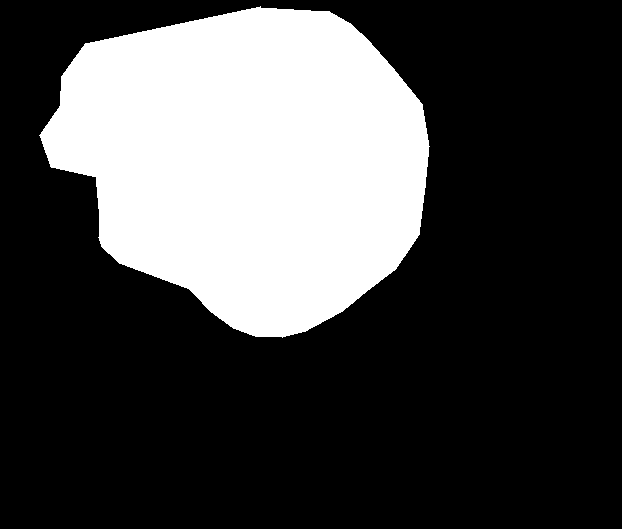

In [7]:
for m in sorted_masks:
    a = visualize(m)
    break

for i in sorted_imgs:
    img = Image.open(i)
    break
a

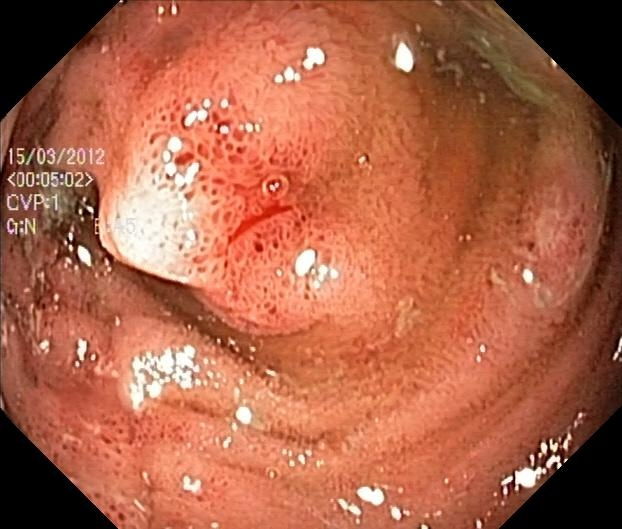

In [8]:
img

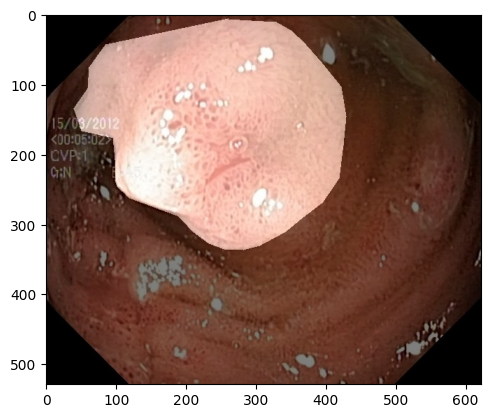

In [9]:
def overlay(img, mask, alpha=0.5):
    base = np.array(img).astype(np.uint8)
    try:
        mask = mask.convert('RGB')
    except:
        mask = Image.fromarray(mask).convert('RGB')
    # print(base.shape, np.array(mask).shape)
    over = (alpha*np.array(mask) + (1-alpha) * base).astype(np.uint8)
    return over

plt.imshow(overlay(img, a))
plt.show()

In [10]:
# 강사님 팁
# 데이터 증강으로 데이터셋을 확보하라
# 기학습된 모델을 이용해라
# 전달할 때 모델과 이미지 입력 사이즈를 알려줘야함(모델에 값을 넣어줄 수 있음)

In [11]:
def data_transform(train):
    def tfm(img, mask):
        img = TF.resize(img,  (IMG_SIZE, IMG_SIZE))
        mask= TF.resize(mask, (IMG_SIZE, IMG_SIZE))
        if train and torch.rand(1) < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        if train and torch.rand(1) < 0.5:
            img = TF.vflip(img)
            mask = TF.vflip(mask)
        if train and torch.rand(1) < 0.5:
            img = TF.rotate(img, 90)
            mask = TF.rotate(mask, 90)
        if train and torch.rand(1) < 0.5:
            img = TF.rotate(img, 180)
            mask = TF.rotate(mask, 180)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # 이미지넷 기준으로 사용
        mask = (np.array(mask) > 127).astype(np.uint8)
        mask = torch.as_tensor(mask, dtype=torch.long)
        return img, mask
    return tfm

class ImgMaskDataset:
    def __init__(self, img_path, mask_path, length, tf=None):
        self.img_path = img_path
        self.mask_path = mask_path
        self.length = length
        self.tf = tf

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        img = Image.open(self.img_path[idx])
        mask = Image.open(self.mask_path[idx])
        mask = np.array(mask)
        mask = Image.fromarray(mask)
        if self.tf:
            img, mask = self.tf(img, mask)
        return img, mask

In [12]:
def get_loader():
    tr_length = int(len(sorted_imgs) * 0.8)
    val_length = len(sorted_imgs)-tr_length
    tr_ds = ImgMaskDataset(sorted_imgs[:tr_length], sorted_masks[:tr_length], tr_length, tf=data_transform(True))
    val_ds = ImgMaskDataset(sorted_imgs[tr_length:], sorted_masks[tr_length:], val_length, tf=data_transform(False))
    tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    return tr_ds, val_ds, tr_ds_loader, val_ds_loader
tr_ds, val_ds, tr_ds_loader, val_ds_loader = get_loader()

In [13]:
x, y = next(iter(tr_ds_loader))
x.shape

torch.Size([16, 3, 384, 384])

In [21]:
import timm

class DoubleConv(nn.Module):
    def __init__(self, inc, outc):
        super().__init__()
        self.c1 = nn.Conv2d(inc, outc, 3, padding=1, bias=True)
        self.c2 = nn.Conv2d(outc, outc, 3, padding=1, bias=True)
        self.r = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.c1(x)
        x = self.r(self.c2(x))
        return x
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)
# class Down(nn.Module):
#     def __init__(self, inc, outc):
#         super().__init__()
#         self.pool = nn.MaxPool2d(2)
#         self.block = DoubleConv(inc, outc)

#     def forward(self, x):
#         x = self.pool(x)
#         x = self.block(x)
#         return x

# class Up(nn.Module):
#     def __init__(self, inc, outc):
#         super().__init__()
#         self.up = nn.ConvTranspose2d(inc, inc//2, 2, stride=2)
#         self.block = DoubleConv(inc, outc)

#     def forward(self, x1, x2):
#         x1 = self.up(x1)
#         # th, tw = x.shape[-2:]
#         # skip = skip[...,:th, :tw]
#         # x = torch.cat([skip, x], dim=1)
#         # x = self.block(x)
#         # return x
#         diffY = x2.size()[2] - x1.size()[2]
#         diffX = x2.size()[3] - x1.size()[3]
#         x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
#         x = torch.cat([x2, x1], dim=1)
#         return self.block(x)

class Up(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(skip_channels + in_channels // 2, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class Unet(nn.Module):
    def __init__(self, n_cls=2):
        super().__init__()
        self.encoder = timm.create_model('efficientnet_b3', pretrained=True, features_only=True, out_indices=(0,1,2,3,4))
        for param in self.encoder.parameters(): # 절대 가중치는 건들지 않는다는 마인드
            param.requires_grad = False
            
        en_chs = self.encoder.feature_info.channels()
        self.up1 = Up(en_chs[4], en_chs[3], en_chs[3])
        self.up2 = Up(en_chs[3], en_chs[2], en_chs[2])
        self.up3 = Up(en_chs[2], en_chs[1], en_chs[1])
        self.up4 = Up(en_chs[1], en_chs[0], en_chs[0])
        self.up_final = nn.ConvTranspose2d(en_chs[0], en_chs[0] // 2, kernel_size=2, stride=2)
        self.final_conv = DoubleConv(en_chs[0] // 2, 32)
        self.outc = nn.Conv2d(32, n_cls, kernel_size=1)
        # self.inc = DoubleConv(inc, base)
        # self.down1 = Down(base, base*2)
        # self.down2 = Down(base*2, base*4)
        # self.down3 = Down(base*4, base*8)
        # self.down4 = Down(base*8, base*16)
        # self.up1 = Down(base*16, base*8)
        # self.up2 = Down(base*8, base*4)
        # self.up3 = Down(base*4, base*2)
        # self.up4 = Down(base*2, base)
        # self.outc = nn.Conv2d(base, n_cls, 1)

    def forward(self, x):
        skips = self.encoder(x)
        s0, s1, s2, s3, s4 = skips
        x = self.up1(s4, s3)
        x = self.up2(x, s2)
        x = self.up3(x, s1)
        x = self.up4(x, s0)
        
        x = self.up_final(x)
        x = self.final_conv(x)
        x = self.outc(x)
        
        # x1 = self.inc(x)
        # x2 = self.down1(x1)
        # x3 = self.down2(x2)
        # x4 = self.down3(x3)
        # x5 = self.down4(x4)

        # x = self.up1(x5, x4)
        # x = self.up2(x, x3)
        # x = self.up3(x, x2)
        # x = self.up4(x, x1)
        # x = self.outc(x)
        return x

In [22]:
m = Unet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
opt = optim.AdamW(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [23]:
def fast_hist(pred, mask, n_class=2):
    pred_flat = pred.flatten()
    mask_flat = mask.flatten()
    hist = np.bincount(
        n_class * mask_flat.astype(int) + pred_flat.astype(int),
        minlength=n_class**2
    ).reshape(n_class, n_class)
    return hist

def miou_from_hist(hist):
    iu = np.diag(hist)/(hist.sum(1)+hist.sum(0)-np.diag(hist)+1e-10)
    return float(np.nanmean(iu)), iu

In [24]:
def train(model, loader, criterion, optimizer, scaler, device, epochs):
    model.train()
    run = 0.0
    t0 = time.time()
    for x, y in tqdm(loader):
        imgs, masks = x.to(device), y.to(device)
        # print(f"Unique values in mask: {torch.unique(masks)}")
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss = criterion(logits, masks.long())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        run += loss.item() * imgs.size(0)
    avg_loss = run/len(loader.dataset)
    print(f'[Epoch{epochs}] tr_loss: {avg_loss} t: {time.time()-t0}')


@torch.no_grad()
def evaluate(model, loader, device, epoch):
    model.eval()
    hist = np.zeros((N_CLASSES, N_CLASSES), dtype=np.float64)
    for batch in tqdm(loader):
        if len(batch) == 3:
            x, y, id_ = batch
        else:
            x, y = batch
        imgs, masks = x.to(device), y.to(device)
        logits = model(imgs)
        preds = torch.argmax(logits, dim=1)
        hist += fast_hist(preds.cpu().numpy(), masks.cpu().numpy(), N_CLASSES)

    miou, iu = miou_from_hist(hist)
    print(f'[Epoch{epoch}] mIoU: {miou*100:.2f}%')
    return miou

In [25]:
BG_COLOR = np.array([0,0,0], dtype=np.uint8) # 배경 
OBJ_COLOR= np.array([200,50,50], dtype=np.uint8) # 객체
def _denorm(img): # 이미지넷 기반의 mean값과 std를 사용
    mean = torch.tensor([0.485, 0.456, 0.406], device=img.device)[:,None,None]
    std = torch.tensor([0.229, 0.224, 0.225], device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1) # 최소 최대 0,1
    return img.detach().cpu().numpy().transpose(1,2,0)

def _colorize_binary(mask_np, ignore_idx=None):
    out = np.zeros((*mask_np.shape, 3), dtype=np.uint8) # 3채널 이미지
    out[mask_np == 0] = BG_COLOR # 0이면 배경
    out[mask_np == 1] = OBJ_COLOR # 객체는 1로 설정
    return out

In [26]:
@torch.no_grad()
def show_samples(model, loader, batches=1, alpha=0.5, max_rows=None):
    model.eval()
    it = iter(loader)
    for _ in range(batches):
        try: batch = next(it)
        except: break
        if len(batch) == 3:
            x, y, _ = batch
        else:
            x, y = batch
        imgs, gts = x.to(DEVICE), y.to(DEVICE)
        logits = model(imgs)
        preds = torch.argmax(logits, dim=1)

        B = imgs.size(0)
        if max_rows is not None:
            B = min(max_rows,B)
        r, c = B, 4 # 전체적 정보를 출력하기 위해 4를 입력
        plt.figure(figsize=(c*4, r*3.5))
        for i in range(B): # 너무 많이 시각화함;;
            img_np = _denorm(imgs[i])
            gt_np = gts[i].detach().cpu().numpy()
            pr_np = preds[i].detach().cpu().numpy()
            gt_rgb = _colorize_binary(gt_np)
            pr_rgb = _colorize_binary(pr_np)
            over = overlay(img_np, pr_rgb, alpha)

            base = i*4
            plt.subplot(r,c,base+1)
            plt.imshow(img_np)
            plt.title('img')
            plt.axis('off')

            plt.subplot(r,c,base+2)
            plt.imshow(gt_rgb)
            plt.title('gt')
            plt.axis('off')
            
            plt.subplot(r,c,base+3)
            plt.imshow(pr_rgb)
            plt.title('pr')
            plt.axis('off')

            plt.subplot(r,c,base+4)
            # plt.imshow(over)
            plt.imshow(img_np)
            plt.imshow(pr_rgb, alpha=alpha)
            plt.title('overlay')
            plt.axis('off')
    plt.show()

In [ ]:
best_miou = -1.0
for ep in range(1, EPOCHS+1):
    train(m, tr_ds_loader, criterion, opt, scaler, DEVICE, epochs=ep)
    miou = evaluate(m, val_ds_loader, DEVICE, ep)
    show_samples(m, val_ds_loader, 1, 0.5, 5)

    if miou > best_miou:
        best_miou = miou
        torch.save({'epoch':ep, 'model': m.state_dict(), 'miou':best_miou, 
                    'config':{
                        'IMG_SIZE': IMG_SIZE, 'N_CLASSES': N_CLASSES, 'LR': LR, 'WEIGHT_DECAY': WEIGHT_DECAY}
                    }, BEST_PATH)
        print(f'best_m_mIoU: {best_miou} -> {BEST_PATH} 저장 진행')

In [ ]:
!nvidia-smi